<a href="https://colab.research.google.com/github/syltaer-utp/Project-S100/blob/main/S100_Equipo2_Parte2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# S100 — Parte II. Proyecto Final
## Gasto en salud y esperanza de vida (América + Europa, 2000–2024)

**Equipo 2** · Universidad Tecnológica de Panamá  
Curso: Introducción a la Ciencia de Datos (S100)

Este cuaderno completa el ciclo de ciencia de datos: limpieza documentada, análisis exploratorio, diseño de evaluación, baseline, dos algoritmos supervisados (árbol de regresión y kNN) con ajuste de hiperparámetros y validación cruzada, tabla comparativa train/test y espacio para interpretación.

**Hipótesis (Parte I):**  
A mayor gasto en salud per cápita (USD), mayor esperanza de vida total, controlando por PIB per cápita, año y continente.

## 1. Librerías y configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.dummy import DummyRegressor
from sklearn.tree import DecisionTreeRegressor, plot_tree
from sklearn.neighbors import KNeighborsRegressor
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.inspection import permutation_importance

sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["axes.labelsize"] = 10

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

## 2. Carga del dataset

Se carga `health_panel.csv` (panel país-año construido a partir de World Bank, WHO y OECD).  
Contiene indicadores de esperanza de vida, gasto en salud, mortalidad, PIB y recursos sanitarios.

In [2]:
DATA_PATH = "health_panel.csv"
df = pd.read_csv(DATA_PATH, low_memory=False)

print(f"Shape original: {df.shape[0]:,} filas × {df.shape[1]} columnas")
print(f"Años: {df['year'].min()} – {df['year'].max()}")
print(f"Países/entidades: {df['country_name'].nunique()}")
print(f"\nColumnas:\n{list(df.columns)}")

Shape original: 17,210 filas × 32 columnas
Años: 1960 – 2024
Países/entidades: 265

Columnas:
['country_code', 'country_name', 'year', 'life_expectancy_total', 'life_expectancy_female', 'life_expectancy_male', 'life_expectancy_gender_gap', 'le_total_yoy_change', 'region', 'income_group', 'iso2_code', 'health_spend_pct_gdp', 'health_spend_per_capita_usd', 'spend_pct_gdp_yoy_change', 'spend_per_capita_yoy_pct', 'hospital_beds_per_1000', 'physicians_per_1000', 'nurses_midwives_per_1000', 'total_health_workers_per_1000', 'infant_mortality_per_1000', 'under5_mortality_per_1000', 'maternal_mortality_per_100k', 'infant_mortality_yoy_change', 'under5_mortality_yoy_change', 'gdp_per_capita_usd', 'population_total', 'log_gdp_per_capita', 'gdp_per_capita_yoy_pct', 'le_per_gdp_point', 'le_per_1k_spend', 'le_spend_residual', 'efficiency_score']


## 3. Limpieza y construcción del subset de trabajo

**Decisiones de limpieza (justificadas):**

1. **Solo países individuales de América y Europa** — se excluyen agregados regionales ("Latin America & Caribbean", "Europe & Central Asia", etc.) para que la unidad de observación sea país-año.
2. **Años ≥ 2000** — mayor cobertura y comparabilidad de gasto en salud; reduce huecos históricos.
3. **Filas con `life_expectancy_total` y `health_spend_per_capita_usd` no nulos** — sin estas dos variables no se puede evaluar la hipótesis.
4. **Eliminación de columnas vacías, códigos ISO y variables derivadas** — no aportan información nueva o están 100 % vacías en el subset.
5. **Creación de `continent`** — variable categórica de control (Américas vs Europa).
6. **Tratamiento de faltantes en predictoras numéricas** — se eliminan filas con PIB nulo antes del split porque el porcentaje es bajo y facilita la comparación de modelos (evita imputación que podría sesgar la comparación entre algoritmos).

In [3]:
americas = [
    "Antigua and Barbuda", "Argentina", "Bahamas, The", "Barbados", "Belize",
    "Bolivia", "Brazil", "Canada", "Chile", "Colombia", "Costa Rica", "Cuba",
    "Dominica", "Dominican Republic", "Ecuador", "El Salvador", "Grenada",
    "Guatemala", "Guyana", "Haiti", "Honduras", "Jamaica", "Mexico",
    "Nicaragua", "Panama", "Paraguay", "Peru", "St. Kitts and Nevis",
    "St. Lucia", "St. Vincent and the Grenadines", "Suriname",
    "Trinidad and Tobago", "United States", "Uruguay", "Venezuela, RB",
]

europe = [
    "Albania", "Austria", "Belarus", "Belgium", "Bosnia and Herzegovina",
    "Bulgaria", "Croatia", "Cyprus", "Czechia", "Denmark", "Estonia",
    "Finland", "France", "Germany", "Greece", "Hungary", "Iceland",
    "Ireland", "Italy", "Latvia", "Lithuania", "Luxembourg", "Malta",
    "Moldova", "Montenegro", "Netherlands", "North Macedonia", "Norway",
    "Poland", "Portugal", "Romania", "Russian Federation", "Serbia",
    "Slovak Republic", "Slovenia", "Spain", "Sweden", "Switzerland",
    "Ukraine", "United Kingdom",
]

# Filtrar países y crear continente
df_ae = df[df["country_name"].isin(americas + europe)].copy()
df_ae["continent"] = np.where(df_ae["country_name"].isin(americas), "Americas", "Europe")

# Años >= 2000
df_ae = df_ae[df_ae["year"] >= 2000].copy()

# Quitar columnas vacías, redundantes y derivadas
cols_eliminar = [
    "region", "income_group", "iso2_code", "country_code",
    "le_per_gdp_point", "le_per_1k_spend", "le_spend_residual", "efficiency_score",
]
df_ae = df_ae.drop(columns=cols_eliminar, errors="ignore")

# Subset final: LE, gasto y PIB no nulos
df_subset = df_ae.dropna(
    subset=["life_expectancy_total", "health_spend_per_capita_usd", "gdp_per_capita_usd"]
).copy()

print(f"df_subset: {df_subset.shape[0]:,} filas × {df_subset.shape[1]} columnas")
print(f"Años: {df_subset['year'].min()} – {df_subset['year'].max()}")
print(f"Países: {df_subset['country_name'].nunique()}")
print("\nPor continente:")
print(df_subset["continent"].value_counts())
print("\nFaltantes residuales:")
print(df_subset[["life_expectancy_total", "health_spend_per_capita_usd",
                 "gdp_per_capita_usd", "year", "continent"]].isnull().sum())

df_subset: 1,786 filas × 25 columnas
Años: 2000 – 2024
Países: 75

Por continente:
continent
Europe      964
Americas    822
Name: count, dtype: int64

Faltantes residuales:
life_expectancy_total          0
health_spend_per_capita_usd    0
gdp_per_capita_usd             0
year                           0
continent                      0
dtype: int64


## 4. Análisis exploratorio

El análisis exploratorio informa las decisiones de modelado: distribución de la variable objetivo, sesgo de las predictoras y relación visual con la hipótesis.

### 4.1 Tabla de estadísticos descriptivos

In [7]:
desc_vars = [
    "life_expectancy_total",
    "health_spend_per_capita_usd",
    "gdp_per_capita_usd",
    "infant_mortality_per_1000",
]
df_desc = df_ae.dropna(subset=["life_expectancy_total"]).copy()

desc = df_subset[desc_vars].describe().T[["mean", "50%", "min", "max", "std"]]
desc = desc.rename(columns={"50%": "median"})
desc = desc.round(2)
print("Tabla 1. Estadísticos descriptivos (subset América + Europa, ≥ 2000)")
print(desc.to_string())

Tabla 1. Estadísticos descriptivos (subset América + Europa, ≥ 2000)
                                 mean    median     min        max       std
life_expectancy_total           75.52     75.66   45.58      84.16      4.79
health_spend_per_capita_usd   1770.71    779.39   18.61   13473.19   2195.96
gdp_per_capita_usd           20610.27  11694.69  440.54  137781.68  22351.27
infant_mortality_per_1000       10.99      7.50    1.50      79.30      9.82


**Espacio para interpretación de la Tabla 1:**  
*(Completar después de ejecutar: media vs mediana, rango, dispersión, implicaciones para el modelado.)*

>

### 4.2 Figura 1 — Distribución de la variable objetivo

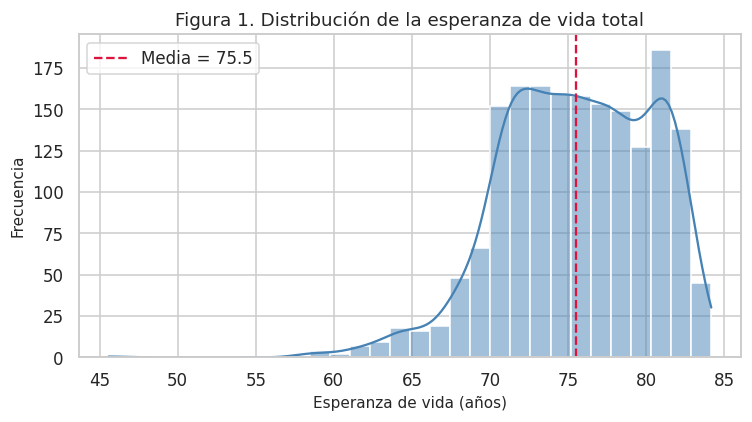

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.histplot(data=df_subset, x="life_expectancy_total", bins=30, kde=True,
             color="steelblue", ax=ax)
ax.axvline(df_subset["life_expectancy_total"].mean(), color="crimson",
           linestyle="--", label=f"Media = {df_subset['life_expectancy_total'].mean():.1f}")
ax.set_title("Figura 1. Distribución de la esperanza de vida total")
ax.set_xlabel("Esperanza de vida (años)")
ax.set_ylabel("Frecuencia")
ax.legend()
plt.tight_layout()
plt.show()

**Espacio para interpretación de la Figura 1:**  
*(Forma de la distribución, colas, implicaciones para RMSE/R².)*

>

### 4.3 Figura 2 — Relación gasto en salud ↔ esperanza de vida (hipótesis)

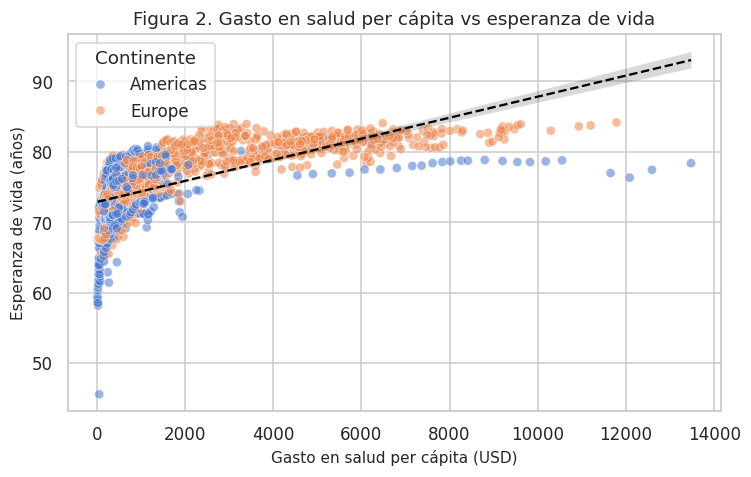

Correlación de Pearson (gasto ↔ LE): 0.685


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))
sns.scatterplot(
    data=df_subset, x="health_spend_per_capita_usd", y="life_expectancy_total",
    hue="continent", alpha=0.55, ax=ax
)
sns.regplot(
    data=df_subset, x="health_spend_per_capita_usd", y="life_expectancy_total",
    scatter=False, color="black", ax=ax, line_kws={"linewidth": 1.5, "linestyle": "--"}
)
ax.set_title("Figura 2. Gasto en salud per cápita vs esperanza de vida")
ax.set_xlabel("Gasto en salud per cápita (USD)")
ax.set_ylabel("Esperanza de vida (años)")
ax.legend(title="Continente")
plt.tight_layout()
plt.show()

corr = df_subset[["health_spend_per_capita_usd", "life_expectancy_total"]].corr().iloc[0, 1]
print(f"Correlación de Pearson (gasto ↔ LE): {corr:.3f}")

**Espacio para interpretación de la Figura 2:**  
*(Dirección de la relación, heterogeneidad por continente, no linealidad aparente, apoyo preliminar a la hipótesis.)*

>

## 5. Definición de X e y

- **y:** `life_expectancy_total` (continua → problema de **regresión**)
- **X:** gasto en salud (variable central de la hipótesis), PIB per cápita, año y continente (controles)

In [10]:
features = [
    "health_spend_per_capita_usd",
    "gdp_per_capita_usd",
    "year",
    "continent",
]

X = df_subset[features].copy()
y = df_subset["life_expectancy_total"].copy()

print(f"X: {X.shape} | y: {y.shape}")
print(f"Faltantes X:\n{X.isnull().sum()}")
print(f"Faltantes y: {y.isnull().sum()}")

X: (1786, 4) | y: (1786,)
Faltantes X:
health_spend_per_capita_usd    0
gdp_per_capita_usd             0
year                           0
continent                      0
dtype: int64
Faltantes y: 0


## 6. Diseño de evaluación: train / test + semilla fija

- 80 % entrenamiento, 20 % prueba.
- `random_state=42` para reproducibilidad.
- Unidad de observación: país-año (no se agrupa por país ni por año).

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE
)

print(f"Train: {X_train.shape[0]} filas")
print(f"Test:  {X_test.shape[0]} filas")

Train: 1428 filas
Test:  358 filas


## 7. Función auxiliar de métricas

Se calculan **RMSE, MAE y R²** tanto en entrenamiento como en prueba para diagnosticar sobreajuste.

In [13]:
def metricas(y_true, y_pred, etiqueta=""):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae  = mean_absolute_error(y_true, y_pred)
    r2   = r2_score(y_true, y_pred)
    if etiqueta:
        print(f"{etiqueta}")
        print(f"  RMSE: {rmse:.3f}")
        print(f"  MAE:  {mae:.3f}")
        print(f"  R²:   {r2:.3f}")
    return {"RMSE": rmse, "MAE": mae, "R²": r2}

## 8. Baseline: predecir siempre la media

El baseline predice el promedio de la esperanza de vida del conjunto de entrenamiento.  
Sirve como **piso de comparación**: cualquier modelo útil debe mejorar RMSE/MAE y obtener R² > 0.

In [14]:
baseline = DummyRegressor(strategy="mean")
baseline.fit(X_train, y_train)

y_pred_b_train = baseline.predict(X_train)
y_pred_b_test  = baseline.predict(X_test)

m_b_train = metricas(y_train, y_pred_b_train, "Baseline — Train")
m_b_test  = metricas(y_test,  y_pred_b_test,  "Baseline — Test")

Baseline — Train
  RMSE: 4.872
  MAE:  3.993
  R²:   0.000
Baseline — Test
  RMSE: 4.464
  MAE:  3.716
  R²:   -0.011


## 9. Modelo 1: Árbol de regresión

**Por qué un árbol:**
1. Variable objetivo continua → regresión.
2. Captura relaciones no lineales (el efecto del gasto no tiene por qué ser lineal).
3. Permite importancia de variables para revisar la hipótesis.

**Preprocesamiento:** One-Hot Encoding de `continent` (sin orden artificial).

**Hiperparámetro:** `max_depth` y `min_samples_leaf` se ajustan con `GridSearchCV` (validación cruzada 5-fold sobre el train).

In [15]:
prep_tree = ColumnTransformer([
    ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), ["continent"]),
    ("num", "passthrough", [
        "health_spend_per_capita_usd",
        "gdp_per_capita_usd",
        "year",
    ]),
])

pipe_tree = Pipeline([
    ("prep", prep_tree),
    ("tree", DecisionTreeRegressor(random_state=RANDOM_STATE)),
])

# Ajuste de hiperparámetros con CV
param_grid_tree = {
    "tree__max_depth": [3, 4, 5, 6, 8, 10, None],
    "tree__min_samples_leaf": [5, 10, 20],
}

gs_tree = GridSearchCV(
    pipe_tree,
    param_grid_tree,
    cv=5,
    scoring="neg_root_mean_squared_error",
    n_jobs=-1,
    refit=True,
)
gs_tree.fit(X_train, y_train)

print("Mejores hiperparámetros (árbol):", gs_tree.best_params_)
print(f"Mejor RMSE CV (negativo → positivo): {-gs_tree.best_score_:.3f}")

best_tree = gs_tree.best_estimator_

y_pred_tree_train = best_tree.predict(X_train)
y_pred_tree_test  = best_tree.predict(X_test)

m_tree_train = metricas(y_train, y_pred_tree_train, "Árbol — Train")
m_tree_test  = metricas(y_test,  y_pred_tree_test,  "Árbol — Test")

Mejores hiperparámetros (árbol): {'tree__max_depth': 6, 'tree__min_samples_leaf': 5}
Mejor RMSE CV (negativo → positivo): 2.301
Árbol — Train
  RMSE: 2.043
  MAE:  1.503
  R²:   0.824
Árbol — Test
  RMSE: 2.334
  MAE:  1.737
  R²:   0.723


### 9.1 Gráficos del árbol de regresión

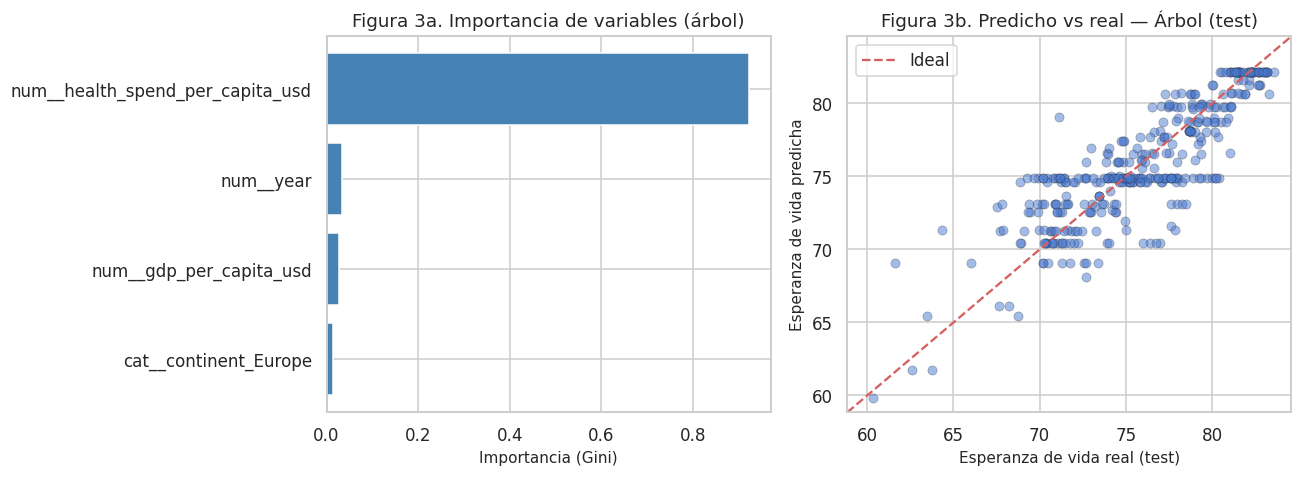


Importancias:
                         feature  importance
num__health_spend_per_capita_usd    0.923453
                       num__year    0.033680
         num__gdp_per_capita_usd    0.028213
           cat__continent_Europe    0.014654


In [16]:
# --- Importancia de variables ---
feature_names = best_tree.named_steps["prep"].get_feature_names_out()
importances = best_tree.named_steps["tree"].feature_importances_
imp_df = pd.DataFrame({"feature": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Importancia
axes[0].barh(imp_df["feature"], imp_df["importance"], color="steelblue")
axes[0].set_title("Figura 3a. Importancia de variables (árbol)")
axes[0].set_xlabel("Importancia (Gini)")

# Predicho vs real (test)
axes[1].scatter(y_test, y_pred_tree_test, alpha=0.5, edgecolor="k", linewidth=0.3)
lims = [min(y_test.min(), y_pred_tree_test.min()) - 1,
        max(y_test.max(), y_pred_tree_test.max()) + 1]
axes[1].plot(lims, lims, "r--", linewidth=1.5, label="Ideal")
axes[1].set_xlim(lims)
axes[1].set_ylim(lims)
axes[1].set_xlabel("Esperanza de vida real (test)")
axes[1].set_ylabel("Esperanza de vida predicha")
axes[1].set_title("Figura 3b. Predicho vs real — Árbol (test)")
axes[1].legend()

plt.tight_layout()
plt.show()

print("\nImportancias:")
print(imp_df.sort_values("importance", ascending=False).to_string(index=False))

## 8. Tabla comparativa de resultados

Se reportan las **mismas tres métricas** en el conjunto de prueba:

Se observa que el árbol mejora RMSE/MAE y sube R² respecto al baseline, eso significa que esta aprendiendo algo útil a partir de las variables.

In [ ]:
tabla = pd.DataFrame({
    "Modelo": ["Baseline (media)", "Árbol de regresión"],
    "RMSE":   [rmse_b, rmse],
    "MAE":    [mae_b, mae],
    "R²":     [r2_b, r2],
})

print(tabla.to_string(index=False, float_format=lambda x: f"{x:.3f}"))

            Modelo  RMSE   MAE     R²
  Baseline (media) 4.464 3.716 -0.011
Árbol de regresión 2.458 1.864  0.693


#Cierre del adelanto

